In [209]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os

In [210]:
def load(filename: str, delimiter: str = " ") -> np.ndarray:
    with open(filename, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    if not lines:
        return np.array([])
    
    
    if len(lines) == 1:#1D
        parts = lines[0].split(delimiter)
        return np.array(parts, dtype=float)
    else:#2D
        data = []
        for line in lines:
            if line:  # 跳过空行
                row = list(map(float, line.split(delimiter)))
                data.append(row)
        return np.array(data, dtype=float)

def load_solution_analytic(directory: str = "."):
    sol_items = []
    ana_items = []

    for fname in os.listdir(directory):
        if not fname.endswith('.txt'):
            continue
        match = re.search(r'\d+\.?\d*', fname)
        if not match:
            continue
        num = float(match.group())
        arr = load(os.path.join(directory, fname))

        if fname.startswith('solution'):
            sol_items.append((num, arr))
        elif fname.startswith('analytic'):
            ana_items.append((num, arr))

    sol_items.sort(key=lambda x: x[0])
    ana_items.sort(key=lambda x: x[0])

    T_sol = np.array([it[0] for it in sol_items], dtype=float) if sol_items else np.array([])
    solutions = [it[1] for it in sol_items]
    T_analy = np.array([it[0] for it in ana_items], dtype=float) if ana_items else np.array([])
    analytics = [it[1] for it in ana_items]

    return T_sol, solutions, T_analy, analytics

In [211]:
T_sol, solutions, T_analy, analytics = load_solution_analytic()
print(T_sol)
print(T_analy)
Xm = load("XM.txt")
Ym = load("YM.txt")

[0.       0.010003 0.020005 0.030008 0.04001  0.050013 0.060015 0.070018
 0.08002  0.090023]
[0.]


In [212]:
def paint(u,T,txt,idx):
    plt.figure()
    cf = plt.contourf(Xm, Ym, u, levels=20, cmap='hot')
    ct = plt.contour(Xm, Ym, u, levels=10, colors='black', linewidths=0.5)
    plt.clabel(ct, inline=True, fontsize=8)
    plt.colorbar(cf, label='u(x,y,t)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(txt + f' at t={T:.3f}')
    plt.axis('equal')
    plt.savefig(txt+str(idx)+".jpg")
    plt.show()

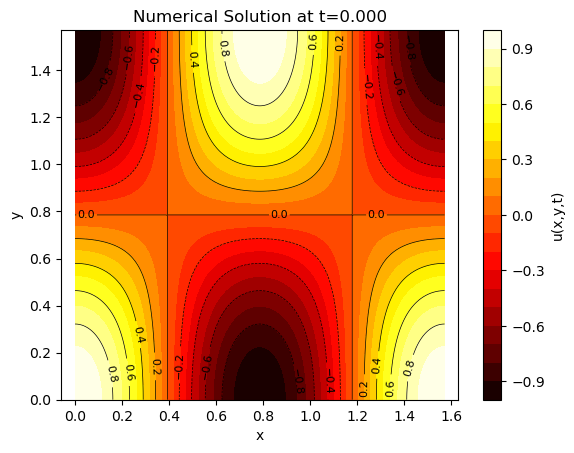

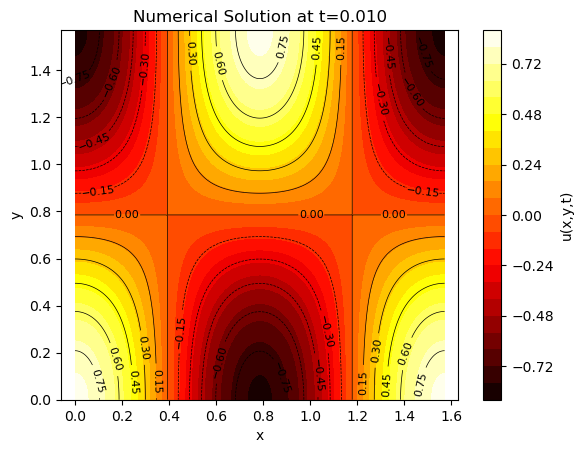

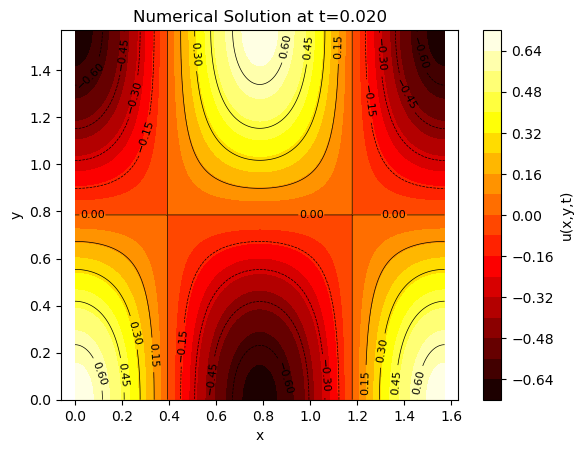

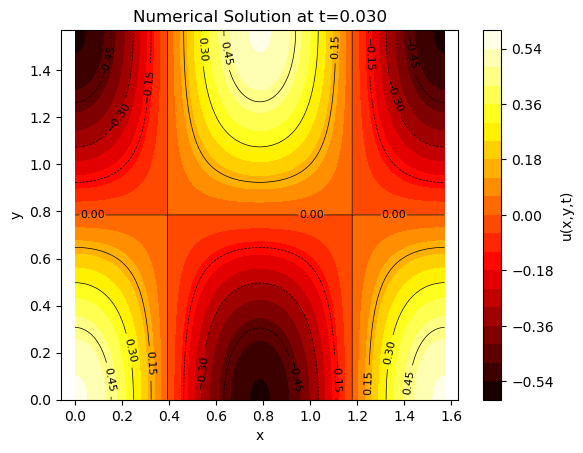

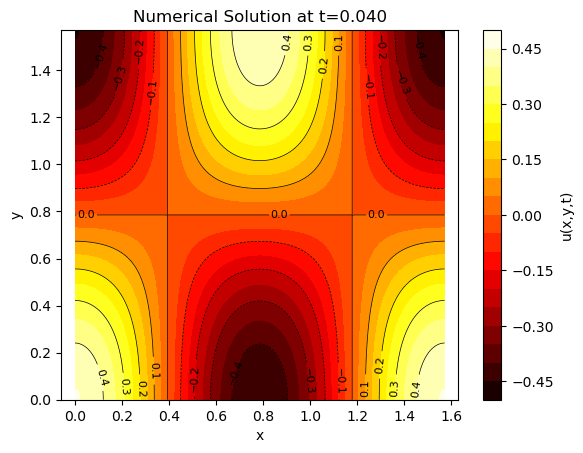

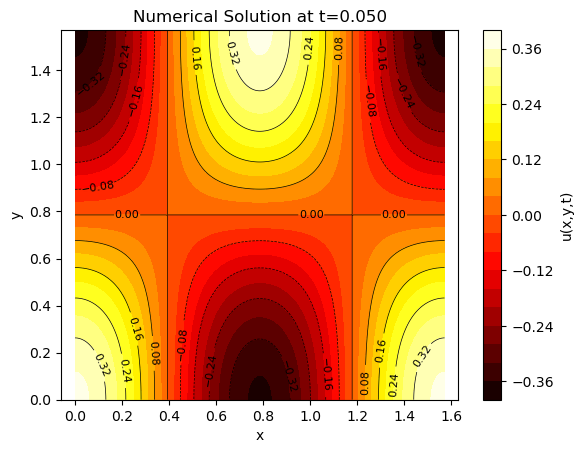

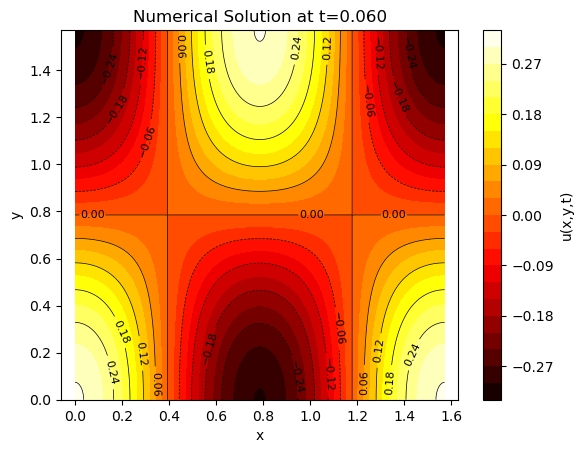

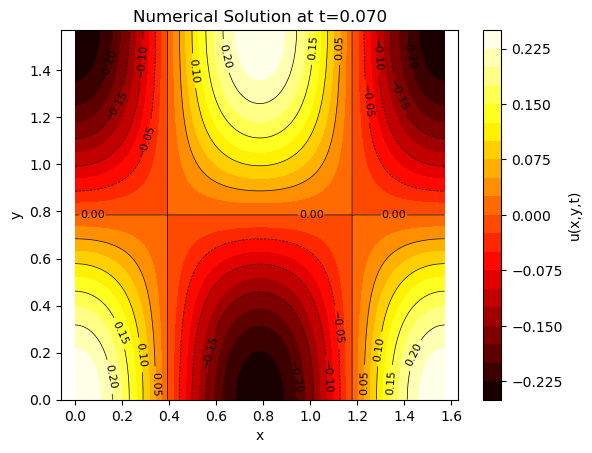

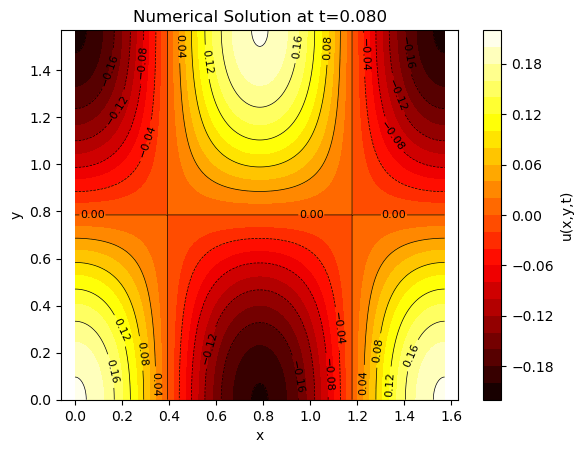

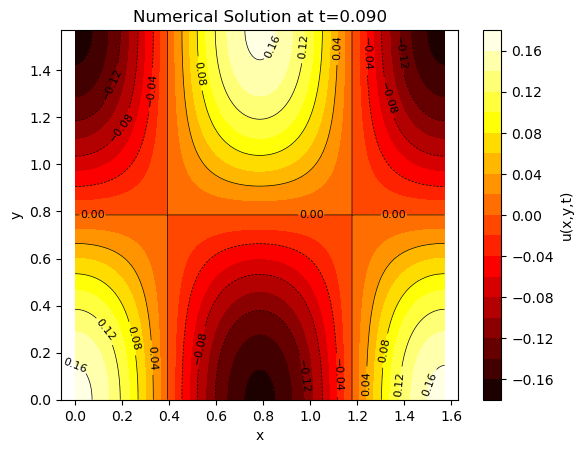

In [213]:
anastr = "Analytic Solution"
numstr = "Numerical Solution"
errstr = "Error"
Nsol=len(T_sol)
Nanaly=len(T_analy)
for i in range(Nsol):
    paint(solutions[i],T_sol[i], numstr,i);

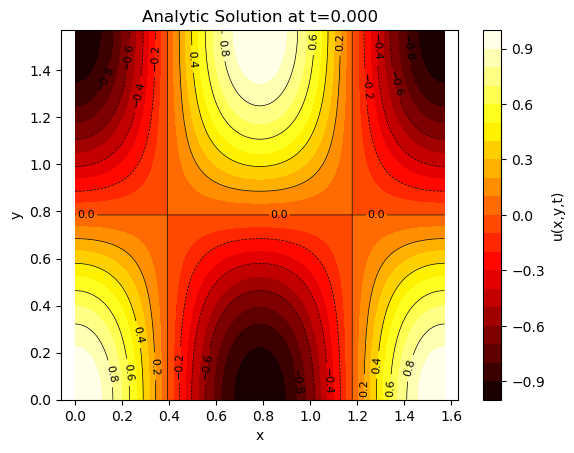

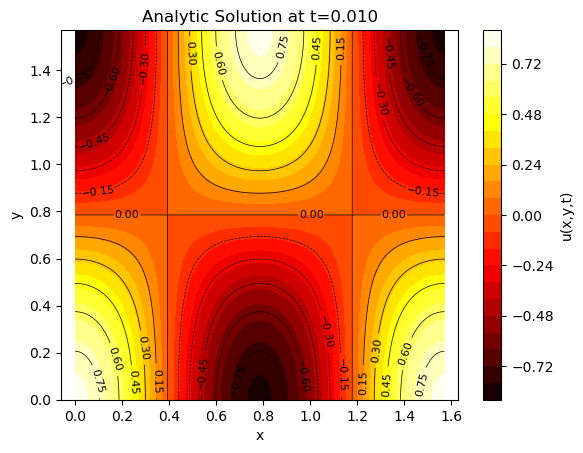

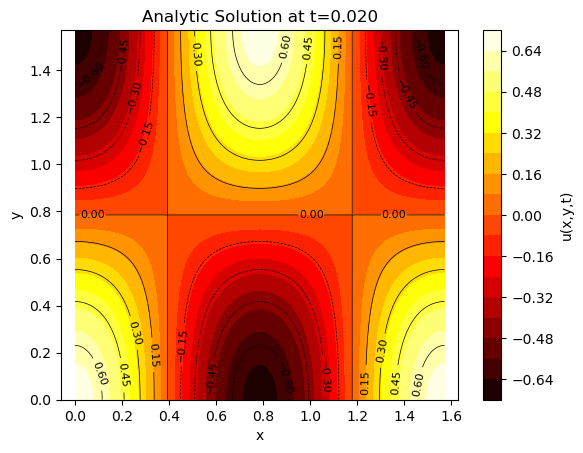

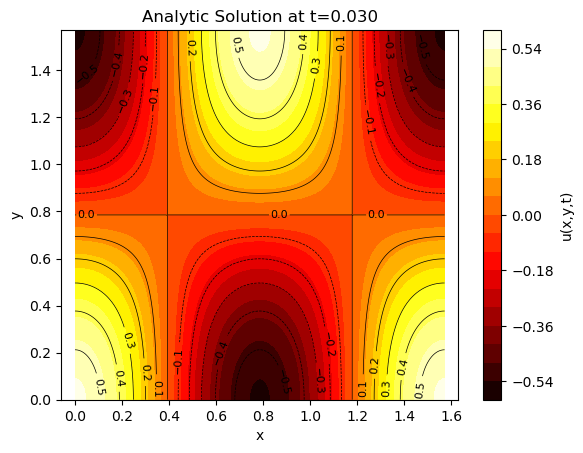

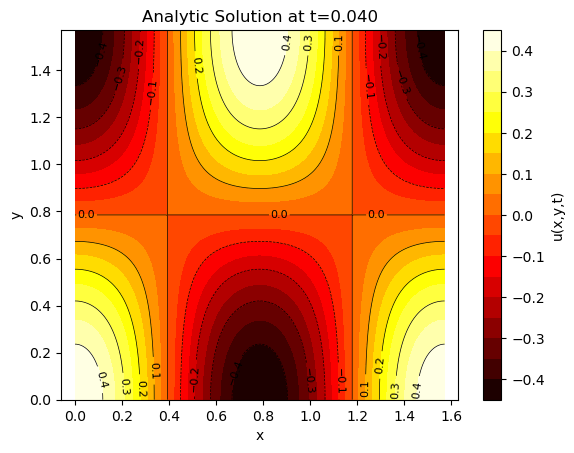

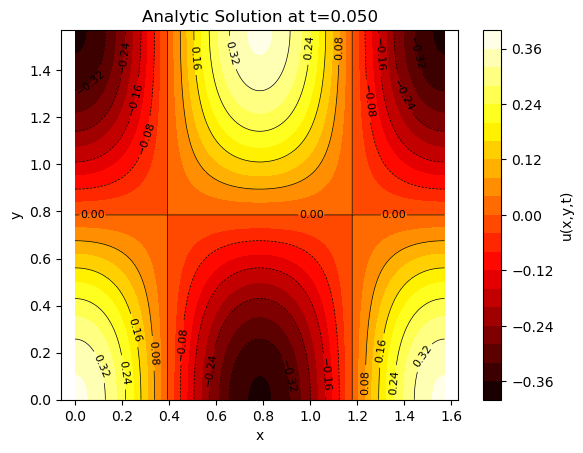

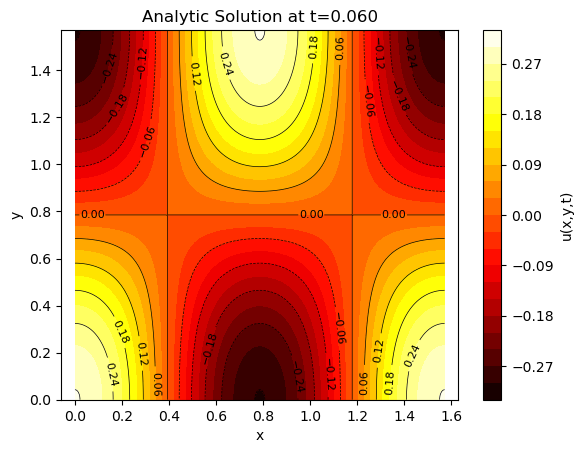

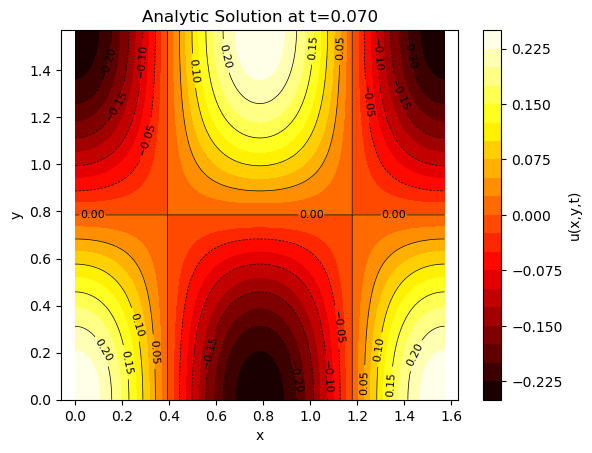

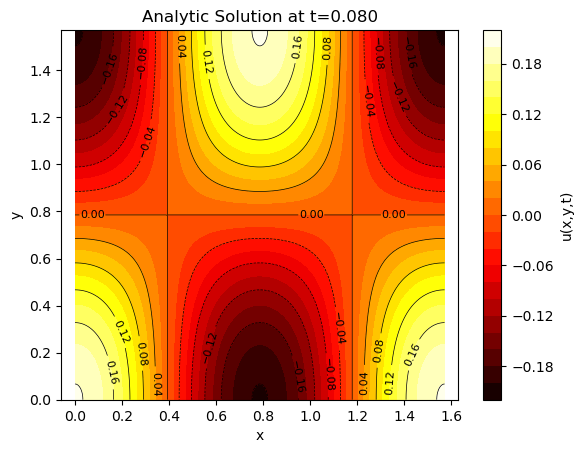

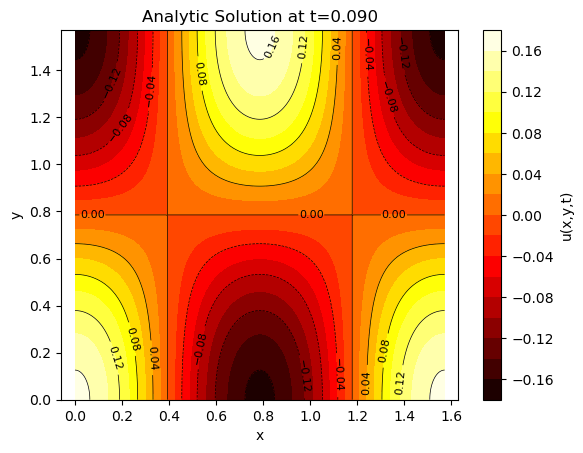

In [214]:
for i in range(Nsol):
    paint(analytics[0]*np.exp(-20*T_sol[i]),T_sol[i], anastr,i)

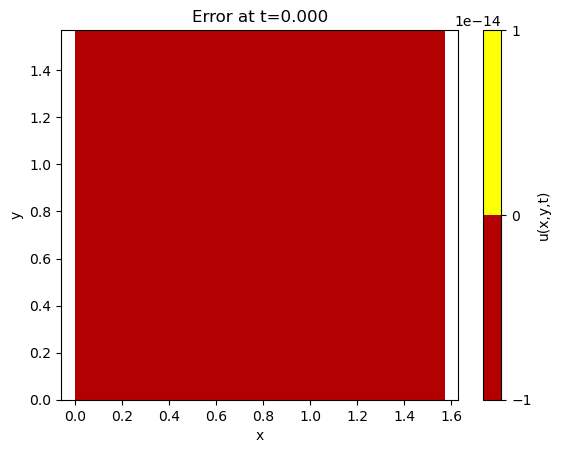

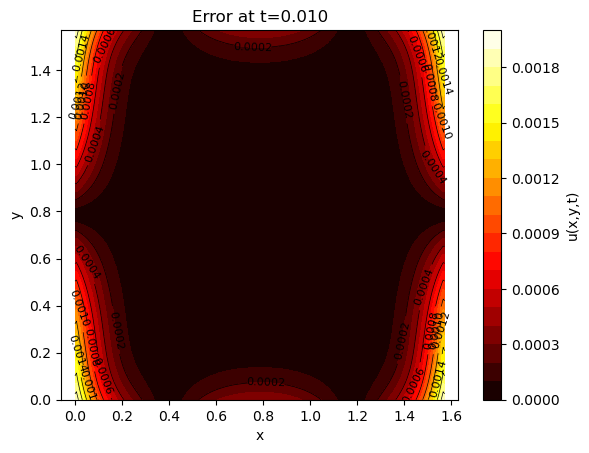

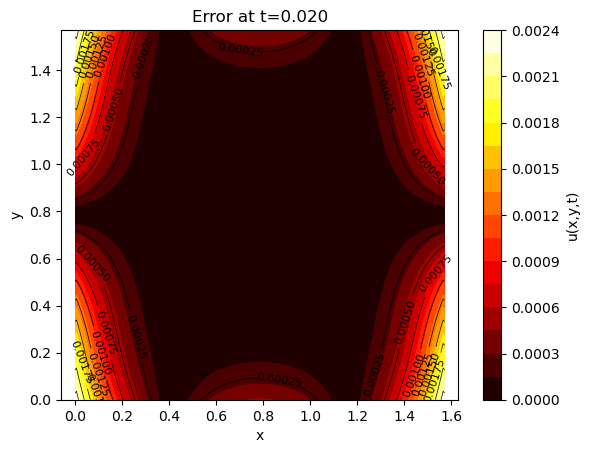

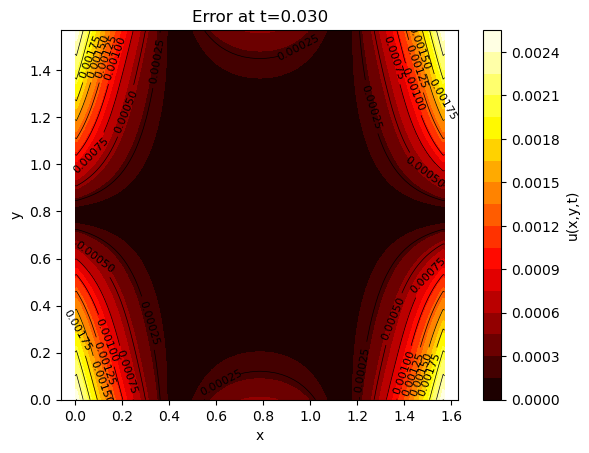

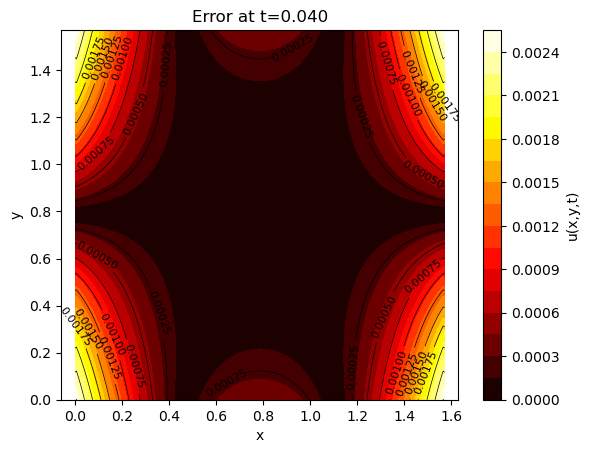

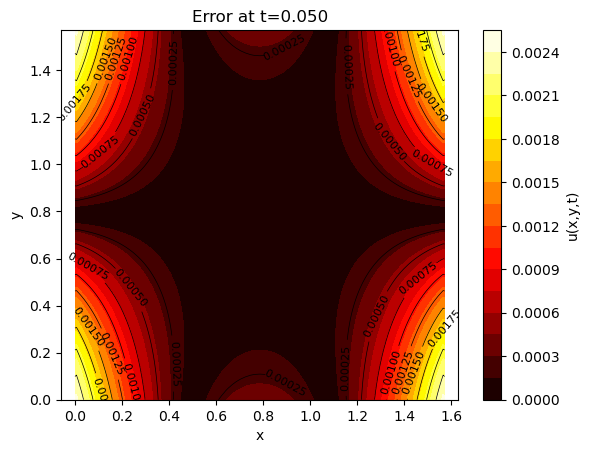

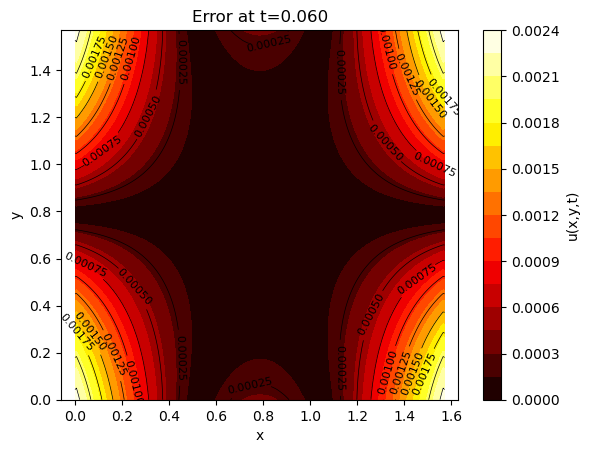

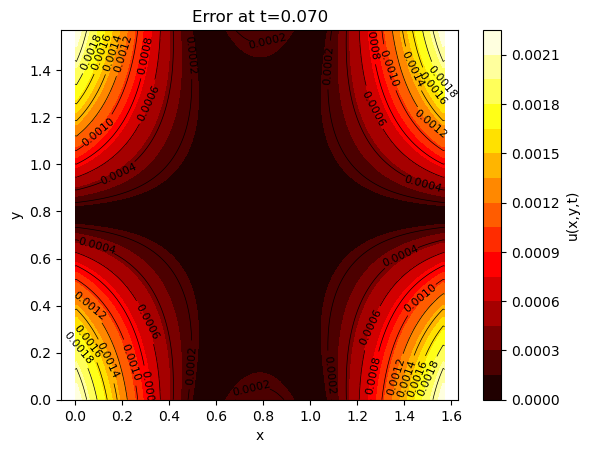

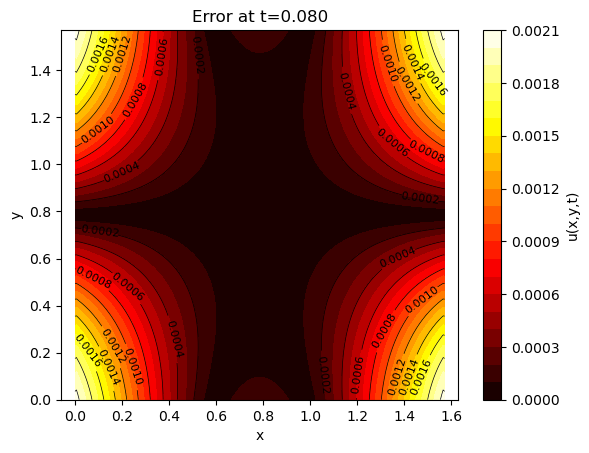

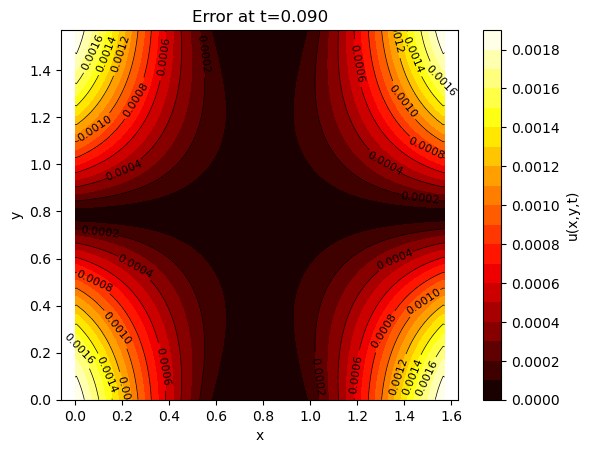

In [215]:
for i in range(Nsol):
    paint(abs(solutions[i]-analytics[0]*np.exp(-20*T_sol[i])),T_sol[i], errstr,i);